In [ ]:
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

SYNTHETIC_DATA_DIR = REPO_ROOT / 'data' / 'synthetic'
RAW_DATA_DIR = REPO_ROOT / 'data' / 'raw'


## Extended Kalman Filter for Synthetic Pendulum Data 
This script implements and compares two variants (augmented vs. non-augmented) of the Extended Kalman Filter for 
state estimation of a pendulum system using synthetic IMU measurements, run over five 
independent trials with different random seeds (42, 7, 123, 256, 999).

Performance is 
evaluated using RMSE and maximum absolute error on orientation and velocity 
states, averaged across all five trials, with trajectory plots drawn from a single 
representative trial (seed 42) for visual clarity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Constants
G  = 9.81
DT = 1 / 100
L  = 1.0

# Noise Parameters
SIGMA_ACCEL      = 0.05
SIGMA_GYRO       = 0.01
SIGMA_BIAS_ACCEL = 0.001
SIGMA_BIAS_GYRO  = 0.0001

GYRO_EFF_VAR  = SIGMA_GYRO**2  + SIGMA_BIAS_GYRO**2  * DT
ACCEL_EFF_VAR = SIGMA_ACCEL**2 + SIGMA_BIAS_ACCEL**2 * DT

SEEDS         = [42, 7, 123, 256, 999]
N_TRIALS      = len(SEEDS)
PLOT_SEED_IDX = 0   # trial used for trajectory plots for clarity (seed 42)


In [2]:
def euler_kinematic_matrix(phi: float, theta: float) -> np.ndarray:
    # Maps body-frame angular velocity ω to Euler-angle rates [φ̇, θ̇, ψ̇].
    sp, cp = np.sin(phi), np.cos(phi)
    ct = np.cos(theta)
    if abs(ct) < 1e-6:
        ct = np.sign(ct) * 1e-6
    tt = np.tan(theta)
    return np.array([
        [1,  sp * tt,   cp * tt ],
        [0,  cp,       -sp      ],
        [0,  sp / ct,   cp / ct ],
    ])


## Augmented EKF  (12-D state: kinematics + bias)

In [3]:
def process_model_aug(x: np.ndarray, z: np.ndarray) -> np.ndarray:
    """Propagate 12-D augmented state.
    x = [φ, θ, ψ,  vx, vy, vz,  bgx, bgy, bgz,  bax, bay, baz]
    z = [ax, ay, az,  ωx, ωy, ωz]
    """
    phi, theta, psi = x[0], x[1], x[2]
    vx, vy, vz      = x[3], x[4], x[5]
    bgx, bgy, bgz   = x[6], x[7], x[8]
    bax, bay, baz   = x[9], x[10], x[11]
    ax, ay, az      = z[0], z[1], z[2]
    wx, wy, wz      = z[3], z[4], z[5]

    # correct measurements for biases
    ax_c = ax - bax;  ay_c = ay - bay;  az_c = az - baz
    wx_c = wx - bgx;  wy_c = wy - bgy;  wz_c = wz - bgz

    # euler angle propagtion
    euler_dot = euler_kinematic_matrix(phi, theta) @ np.array([wx_c, wy_c, wz_c])
    phi_new   = phi   + DT * euler_dot[0] 
    theta_new = theta + DT * euler_dot[1]
    psi_new   = psi   + DT * euler_dot[2]

    # velocity propagation (accounting for gravity in the inertial frame)
    theta_dot_c = z[4] - bgy 
    vx_new = vx + DT * (ax_c - G * np.sin(theta)) 
    vy_new = vy + DT * (ay_c + G * np.sin(phi) * np.cos(theta))
    vz_new = vz + DT * (az_c + L * theta_dot_c**2 - G * np.cos(phi) * np.cos(theta))

    return np.array([phi_new, theta_new, psi_new, vx_new, vy_new, vz_new,
                     bgx, bgy, bgz, bax, bay, baz])


def jacobian_F_aug(x: np.ndarray, z: np.ndarray) -> np.ndarray:
    """∂f/∂x  (12×12)."""
    phi, theta    = x[0], x[1]
    bgx, bgy, bgz = x[6], x[7], x[8]
    # Bias-corrected gyroscope readings
    wx_c = z[3] - bgx;  wy_c = z[4] - bgy;  wz_c = z[5] - bgz

    sp, cp = np.sin(phi), np.cos(phi)
    st, ct = np.sin(theta), np.cos(theta)
    tt     = st / (ct + 1e-9);  sec_t = 1.0 / (ct + 1e-9)
    T      = euler_kinematic_matrix(phi, theta) 

    # ∂(orientation update)/∂(orientation)     
    F = np.eye(12)
    F[0, 0] = 1 + DT * (wy_c * cp * tt    - wz_c * sp * tt)
    F[0, 1] =     DT * (wy_c * sp * sec_t**2 + wz_c * cp * sec_t**2)
    F[1, 0] =     DT * (-wy_c * sp - wz_c * cp)
    F[1, 1] = 1.0
    F[2, 0] =     DT * (wy_c * cp * sec_t - wz_c * sp * sec_t)
    F[2, 1] =     DT * (wy_c * sp * sec_t * tt + wz_c * cp * sec_t * tt)

    # ∂(velocity update)/∂(orientation)
    F[3, 1] = -DT * G * ct
    F[4, 0] =  DT * G * cp * ct;  F[4, 1] = -DT * G * sp * st
    F[5, 0] =  DT * G * sp * ct;  F[5, 1] =  DT * G * cp * st

    # ∂(orientation update)/∂(gyro biases)
    for row in range(3):
        for col in range(3):
            F[row, 6 + col] = -DT * T[row, col]
    
    # ∂(velocity update)/∂(accelerometer biases) 
    F[3, 9]  = -DT;  
    F[4, 10] = -DT; 
    F[5, 11] = -DT
    F[5, 7]  =  DT * (-2 * L * (z[4] - bgy)) # centripetal correction v_z with respect to the gyro bias bgy
    return F


def measurement_model_accel_aug(x: np.ndarray, z: np.ndarray) -> np.ndarray:
    """
    Predicted accelerometer measurement h_accel(x).
    Inputs:
        x : augmented state vector (12,)
        z : raw IMU measurement vector (6,)
    Returns:
        h : predicted accelerometer reading (3,) = [h_ax, h_ay, h_az]
    """
    phi, theta    = x[0], x[1];  bgy = x[7]
    bax, bay, baz = x[9], x[10], x[11]
    sp, cp = np.sin(phi), np.cos(phi)
    st, ct = np.sin(theta), np.cos(theta)
    theta_dot = z[4] - bgy
    # gravity and centripetal terms are added to the bias-corrected accelerometer reading to get the predicted measurement.
    return np.array([G * st + bax,
                     -G * sp * ct + bay,
                     -L * theta_dot**2 + G * cp * ct + baz])



def jacobian_H_accel_aug(x: np.ndarray, z: np.ndarray) -> np.ndarray:
    # Jacobian H_gyro = ∂h_gyro/∂x  (3×12) for the augmented state.
    phi, theta = x[0], x[1];  bgy = x[7]
    sp, cp = np.sin(phi), np.cos(phi)
    st, ct = np.sin(theta), np.cos(theta)
    theta_dot = z[4] - bgy
    H = np.zeros((3, 12))
    H[0, 1]  =  G * ct
    H[1, 0]  = -G * cp * ct;  H[1, 1] =  G * sp * st
    H[2, 0]  = -G * sp * ct;  H[2, 1] = -G * cp * st
    H[2, 7]  =  2 * L * theta_dot
    H[0, 9]  = H[1, 10] = H[2, 11] = 1.0
    return H


def measurement_model_gyro_aug(x: np.ndarray) -> np.ndarray:
    # Predicted gyroscope measurement h_gyro(x) for the augmented state.
    vx = x[3];  bgx, bgy, bgz = x[6], x[7], x[8];  theta = x[1]
    ct = np.cos(theta)
    if abs(ct) < 1e-6: ct = np.sign(ct) * 1e-6
    return np.array([bgx, vx / (L * ct) + bgy, bgz])


def jacobian_H_gyro_aug(x: np.ndarray) -> np.ndarray:
    """H_gyro (3×12)."""
    vx = x[3];  theta = x[1]
    st, ct = np.sin(theta), np.cos(theta)
    if abs(ct) < 1e-6: ct = np.sign(ct) * 1e-6
    H = np.zeros((3, 12))
    H[1, 1] = vx * st / (L * ct**2);  H[1, 3] = 1.0 / (L * ct)
    H[0, 6] = H[1, 7] = H[2, 8] = 1.0
    return H


def measurement_model_vz_aug(x: np.ndarray, z: np.ndarray) -> np.ndarray:
    # Predicted vertical velocity measurement h_vz(x) for the augmented state. 
    # This is included as a separate measurement update because the IMU alone cannot 
    # directly observe the bob's vertical velocity; instead, we derive it from the
    # pendulum geometry as vz = L·sin(θ)·θ̇_c, where θ̇_c = z[4] − b_gy is the
    # bias-corrected pitch rate. This kinematic constraint couples the rotational
    # and translational states, providing an additional correction signal to prevent
    # z-velocity drift.
    theta = x[1];  bgy = x[7]
    theta_dot = z[4] - bgy
    return np.array([L * np.sin(theta) * theta_dot])


In [4]:
class EKFAugmented:
    """12-D EKF: state = [φ,θ,ψ, vx,vy,vz, bgx,bgy,bgz, bax,bay,baz]."""
    # STANDARD EXTENDED KALMAN FILTER IMPLEMENTATION WITH AUGMENTED STATE TO ESTIMATE GYRO AND ACCELEROMETER BIASES.
    def __init__(self):
        orient_noise    = (SIGMA_GYRO       * DT) ** 2
        vel_noise       = (SIGMA_ACCEL      * DT) ** 2
        gyro_bias_noise =  SIGMA_BIAS_GYRO  ** 2  * DT
        acc_bias_noise  =  SIGMA_BIAS_ACCEL ** 2  * DT
        self.Q       = np.diag([orient_noise]*3 + [vel_noise]*3 +
                               [gyro_bias_noise]*3 + [acc_bias_noise]*3)
        self.R_accel = np.diag([SIGMA_ACCEL**2 * 0.1] * 3)
        self.R_gyro  = np.diag([SIGMA_GYRO**2] * 3)
        self.R_vy    = np.array([[SIGMA_ACCEL**2]])
        self.x = np.zeros(12)
        self.P = np.diag([0.1]*6 + [1e-6]*6)

    def initialise_from_measurement(self, z):
        self.x[1]            = np.arctan2(z[0], z[2])
        self.x[0]            = np.arctan2(-z[1], np.sqrt(z[0]**2 + z[2]**2))
        self.P[0, 0] = self.P[1, 1] = 0.01

    def _update(self, H, y, R):
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(len(self.x)) - K @ H) @ self.P

    def predict(self, z):
        F      = jacobian_F_aug(self.x, z)
        self.x = process_model_aug(self.x, z)
        self.P = F @ self.P @ F.T + self.Q

    def update_accel(self, z):
        self._update(jacobian_H_accel_aug(self.x, z),
                     z[:3] - measurement_model_accel_aug(self.x, z),
                     self.R_accel)

    def update_gyro(self, z):
        self._update(jacobian_H_gyro_aug(self.x),
                     z[3:6] - measurement_model_gyro_aug(self.x),
                     self.R_gyro)

    def update_vz(self, z):
        st   = np.sin(self.x[1])
        R_vz = np.array([[(L * st * SIGMA_GYRO)**2]])
        H    = np.zeros((1, 12));  H[0, 5] = 1.0
        y    = measurement_model_vz_aug(self.x, z) - np.array([self.x[5]])
        self._update(H, y.flatten(), R_vz)

    def update_vy(self):
        H = np.zeros((1, 12));  H[0, 4] = 1.0
        self._update(H, np.array([0.0 - self.x[4]]), self.R_vy)

    def step(self, z):
        self.predict(z);  self.update_accel(z)
        self.update_gyro(z);  self.update_vz(z);  self.update_vy()
        return self.x.copy()


## Non-Augmented EKF  (6-D state: bias absorbed into Q)

In [5]:
# The non-augmented EKF implementation is provided for comparison. 
# the only difference is that the state is 6-D and does not include bias terms, and the process and measurement models are adjusted accordingly.
def process_model_non_aug(x: np.ndarray, z: np.ndarray) -> np.ndarray:
    """6-D state propagation. x = [φ,θ,ψ, vx,vy,vz]. Bias absorbed into Q."""
    phi, theta, psi = x[0], x[1], x[2]
    vx, vy, vz      = x[3], x[4], x[5]
    ax, ay, az      = z[0], z[1], z[2]
    wx, wy, wz      = z[3], z[4], z[5]

    ct = np.cos(theta)
    if abs(ct) < 1e-6: ct = np.sign(ct) * 1e-6

    euler_dot     = euler_kinematic_matrix(phi, theta) @ np.array([wx, wy, wz])
    phi_new       = phi   + DT * euler_dot[0]
    theta_new     = theta + DT * euler_dot[1]
    psi_new       = psi   + DT * euler_dot[2]

    theta_dot_kin = vx / (L * ct)
    vx_new = vx + DT * (ax - G * np.sin(theta))
    vy_new = vy + DT * (ay + G * np.sin(phi) * np.cos(theta))
    vz_new = vz + DT * (az + L * theta_dot_kin**2 - G * np.cos(phi) * np.cos(theta))

    return np.array([phi_new, theta_new, psi_new, vx_new, vy_new, vz_new])


def jacobian_F_non_aug(x: np.ndarray, z: np.ndarray) -> np.ndarray:
    """∂f/∂x  (6×6)."""
    phi, theta = x[0], x[1];  vx = x[3]
    wx, wy, wz = z[3], z[4], z[5]
    sp, cp = np.sin(phi), np.cos(phi)
    st, ct = np.sin(theta), np.cos(theta)
    if abs(ct) < 1e-6: ct = np.sign(ct) * 1e-6
    tt = st / ct;  sec_t = 1.0 / ct

    F = np.eye(6)
    F[0, 0] = 1 + DT * (wy * cp * tt    - wz * sp * tt)
    F[0, 1] =     DT * (wy * sp * sec_t**2 + wz * cp * sec_t**2)
    F[1, 0] =     DT * (-wy * sp - wz * cp)
    F[1, 1] = 1.0
    F[2, 0] =     DT * (wy * cp * sec_t - wz * sp * sec_t)
    F[2, 1] =     DT * (wy * sp * sec_t * tt + wz * cp * sec_t * tt)
    F[3, 1] = -DT * G * ct
    F[4, 0] =  DT * G * cp * ct;  F[4, 1] = -DT * G * sp * st
    F[5, 0] =  DT * G * sp * ct
    F[5, 1] =  DT * (G * cp * st  +  2.0 * vx**2 * st / (L * ct**3))
    F[5, 3] =  DT * 2.0 * vx / (L * ct**2)
    return F


def measurement_model_accel_non_aug(x: np.ndarray) -> np.ndarray:
    phi, theta = x[0], x[1];  vx = x[3]
    sp, cp = np.sin(phi), np.cos(phi)
    st, ct = np.sin(theta), np.cos(theta)
    if abs(ct) < 1e-6: ct = np.sign(ct) * 1e-6
    theta_dot_kin = vx / (L * ct)
    return np.array([G * st, -G * sp * ct, -L * theta_dot_kin**2 + G * cp * ct])


def jacobian_H_accel_non_aug(x: np.ndarray) -> np.ndarray:
    """H_accel (3×6)."""
    phi, theta = x[0], x[1];  vx = x[3]
    sp, cp = np.sin(phi), np.cos(phi)
    st, ct = np.sin(theta), np.cos(theta)
    if abs(ct) < 1e-6: ct = np.sign(ct) * 1e-6
    H = np.zeros((3, 6))
    H[0, 1] =  G * ct
    H[1, 0] = -G * cp * ct;  H[1, 1] =  G * sp * st
    H[2, 0] = -G * sp * ct
    H[2, 1] = -G * cp * st - 2.0 * vx**2 * st / (L * ct**3)
    H[2, 3] = -2.0 * vx / (L * ct**2)
    return H


def measurement_model_gyro_non_aug(x: np.ndarray) -> np.ndarray:
    vx, theta = x[3], x[1]
    ct = np.cos(theta)
    if abs(ct) < 1e-6: ct = np.sign(ct) * 1e-6
    return np.array([0.0, vx / (L * ct), 0.0])


def jacobian_H_gyro_non_aug(x: np.ndarray) -> np.ndarray:
    """H_gyro (3×6)."""
    vx, theta = x[3], x[1]
    st, ct = np.sin(theta), np.cos(theta)
    if abs(ct) < 1e-6: ct = np.sign(ct) * 1e-6
    H = np.zeros((3, 6))
    H[1, 1] = vx * st / (L * ct**2);  H[1, 3] = 1.0 / (L * ct)
    return H


def measurement_model_vz_non_aug(x: np.ndarray) -> np.ndarray:
    theta, vx = x[1], x[3]
    ct = np.cos(theta)
    if abs(ct) < 1e-6: ct = np.sign(ct) * 1e-6
    return np.array([vx * np.sin(theta) / ct])


In [6]:
class EKFNonAugmented:
    """6-D EKF: state = [φ,θ,ψ, vx,vy,vz]. Bias uncertainty absorbed into Q."""

    def __init__(self):
        orient_noise = GYRO_EFF_VAR  * DT**2
        vel_noise    = ACCEL_EFF_VAR * DT**2
        self.Q       = np.diag([orient_noise]*3 + [vel_noise]*3)
        self.R_accel = np.diag([SIGMA_ACCEL**2] * 3)
        self.R_gyro  = np.diag([SIGMA_GYRO**2]  * 3)
        self.R_vy    = np.array([[SIGMA_ACCEL**2]])
        self.x = np.zeros(6)
        self.P = np.diag([0.1] * 6)

    def initialise_from_measurement(self, z):
        self.x[1]            = np.arctan2(z[0], z[2])
        self.x[0]            = np.arctan2(-z[1], np.sqrt(z[0]**2 + z[2]**2))
        self.P[0, 0] = self.P[1, 1] = 0.01

    def _update(self, H, y, R):
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(len(self.x)) - K @ H) @ self.P

    def predict(self, z):
        F      = jacobian_F_non_aug(self.x, z)
        self.x = process_model_non_aug(self.x, z)
        self.P = F @ self.P @ F.T + self.Q

    def update_accel(self, z):
        self._update(jacobian_H_accel_non_aug(self.x),
                     z[:3] - measurement_model_accel_non_aug(self.x),
                     self.R_accel)

    def update_gyro(self, z):
        self._update(jacobian_H_gyro_non_aug(self.x),
                     z[3:6] - measurement_model_gyro_non_aug(self.x),
                     self.R_gyro)

    def update_vz(self):
        st   = np.sin(self.x[1])
        R_vz = np.array([[(L * st * SIGMA_GYRO)**2]])
        H    = np.zeros((1, 6));  H[0, 5] = 1.0
        y    = measurement_model_vz_non_aug(self.x) - np.array([self.x[5]])
        self._update(H, y.flatten(), R_vz)

    def update_vy(self):
        H = np.zeros((1, 6));  H[0, 4] = 1.0
        self._update(H, np.array([0.0 - self.x[4]]), self.R_vy)

    def step(self, z):
        self.predict(z);  self.update_accel(z)
        self.update_gyro(z);  self.update_vz();  self.update_vy()
        return self.x.copy()


## Run 5 trials  (load pre-generated .npz files)

In [7]:
@dataclass
class TrialResult:
    label:       str
    gt:          dict
    estimates:   np.ndarray
    rmse_angles: np.ndarray
    rmse_vel:    np.ndarray
    mae_angles:  np.ndarray
    mae_vel:     np.ndarray
    max_angles:  np.ndarray
    max_vel:     np.ndarray


def run_ekf(Z: np.ndarray, gt: dict, ekf_cls, label: str = '') -> TrialResult:
    """Run one EKF class over a dataset and return a TrialResult."""
    N   = len(Z)
    ekf = ekf_cls()
    ekf.initialise_from_measurement(Z[0])

    estimates = np.zeros((N, len(ekf.x)))
    for k in range(N):
        estimates[k] = ekf.step(Z[k])

    gt_state = np.array([gt['roll'], gt['pitch'], gt['yaw'],
                         gt['vx'],   gt['vy'],    gt['vz']]).T

    err_ang = estimates[:, 0:3] - gt_state[:, 0:3]
    err_vel = estimates[:, 3:6] - gt_state[:, 3:6]

    return TrialResult(
        label       = label,
        gt          = gt,
        estimates   = estimates,
        rmse_angles = np.sqrt(np.mean(err_ang**2, axis=0)),
        rmse_vel    = np.sqrt(np.mean(err_vel**2, axis=0)),
        mae_angles  = np.mean(np.abs(err_ang), axis=0),
        mae_vel     = np.mean(np.abs(err_vel), axis=0),
        max_angles  = np.max(np.abs(err_ang),  axis=0),
        max_vel     = np.max(np.abs(err_vel),  axis=0),
    )


def mean_result(results, label: str) -> TrialResult:
    """Average metrics across trials; keep trajectory from PLOT_SEED_IDX for clarity reason."""
    return TrialResult(
        label       = label,
        gt          = results[PLOT_SEED_IDX].gt,
        estimates   = results[PLOT_SEED_IDX].estimates,
        rmse_angles = np.mean([r.rmse_angles for r in results], axis=0),
        rmse_vel    = np.mean([r.rmse_vel    for r in results], axis=0),
        mae_angles  = np.mean([r.mae_angles  for r in results], axis=0),
        mae_vel     = np.mean([r.mae_vel     for r in results], axis=0),
        max_angles  = np.mean([r.max_angles  for r in results], axis=0),
        max_vel     = np.mean([r.max_vel     for r in results], axis=0),
    )


In [8]:
results_aug     = []
results_non_aug = []

for i, seed in enumerate(SEEDS):
    data = np.load(SYNTHETIC_DATA_DIR / f'synthetic_data_pendulum_seed{seed}.npz', allow_pickle=True)
    Z    = data['Z']
    gt   = data['gt'].item()

    results_aug.append(    run_ekf(Z, gt, EKFAugmented,    label=f'Augmented seed={seed}'))
    results_non_aug.append(run_ekf(Z, gt, EKFNonAugmented, label=f'Non-Augmented seed={seed}'))

    print(f"Trial {i+1}  seed={seed:>4d}  |  "
          f"Aug RMSE θ={results_aug[-1].rmse_angles[1]:.4f} rad  "
          f"NonAug RMSE θ={results_non_aug[-1].rmse_angles[1]:.4f} rad")

# Average metrics across 5 trials; trajectory from PLOT_SEED_IDX (seed 42)
result_aug     = mean_result(results_aug,     'Augmented (12-D)  — avg 5 trials')
result_non_aug = mean_result(results_non_aug, 'Non-Augmented (6-D) — avg 5 trials')

print(f"\nAvg RMSE angles  Aug:     {result_aug.rmse_angles}")
print(f"Avg RMSE angles  Non-Aug: {result_non_aug.rmse_angles}")


Trial 1  seed=  42  |  Aug RMSE θ=0.2916 rad  NonAug RMSE θ=0.2623 rad
Trial 2  seed=   7  |  Aug RMSE θ=0.2916 rad  NonAug RMSE θ=0.2623 rad
Trial 3  seed= 123  |  Aug RMSE θ=0.2911 rad  NonAug RMSE θ=0.2622 rad
Trial 4  seed= 256  |  Aug RMSE θ=0.2918 rad  NonAug RMSE θ=0.2627 rad
Trial 5  seed= 999  |  Aug RMSE θ=0.2914 rad  NonAug RMSE θ=0.2626 rad

Avg RMSE angles  Aug:     [0.00115159 0.29150896 0.00219209]
Avg RMSE angles  Non-Aug: [0.00087168 0.26242817 0.00268764]


## Trajectory plots  (seed 42 only, for clarity)

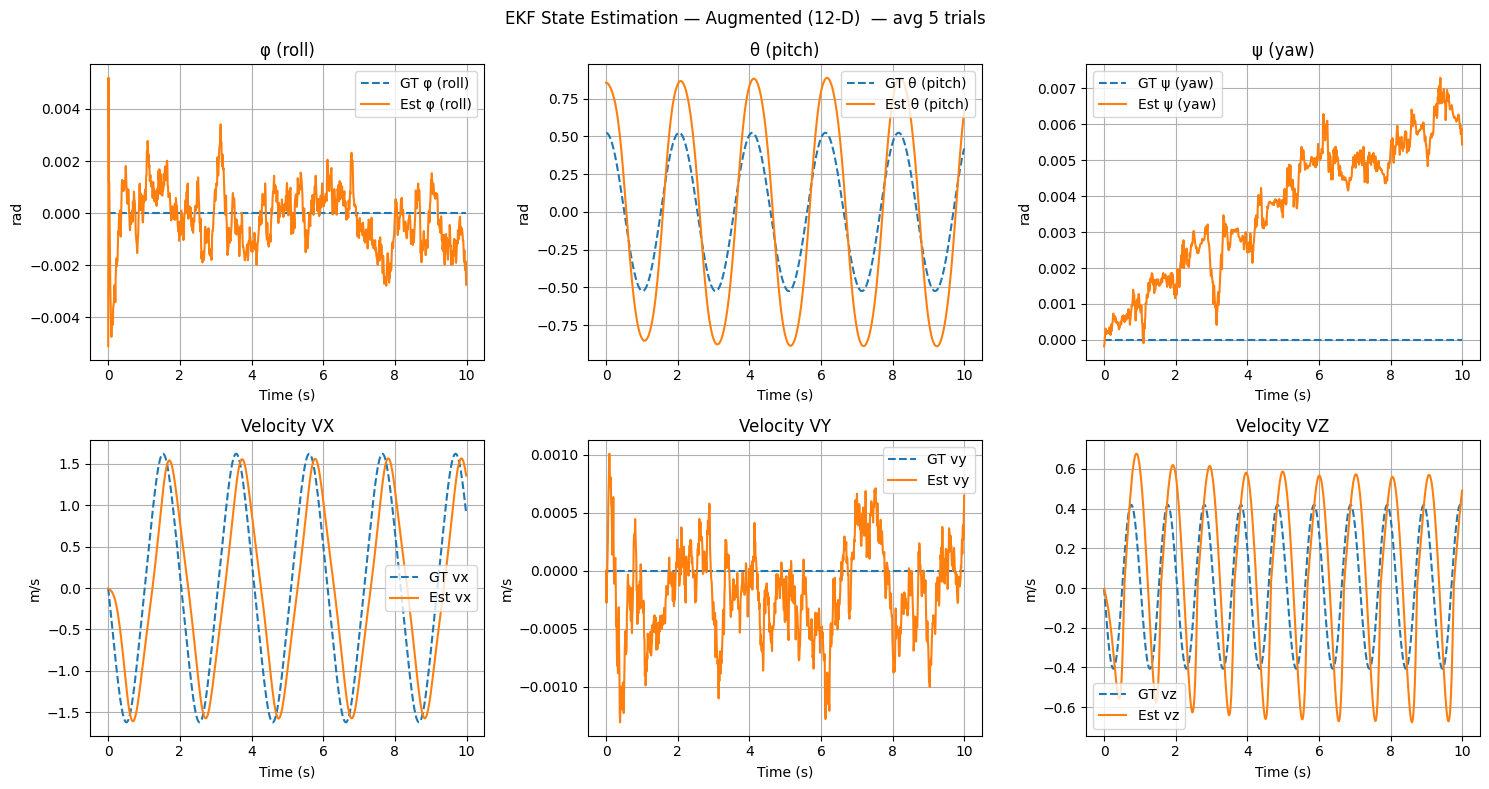

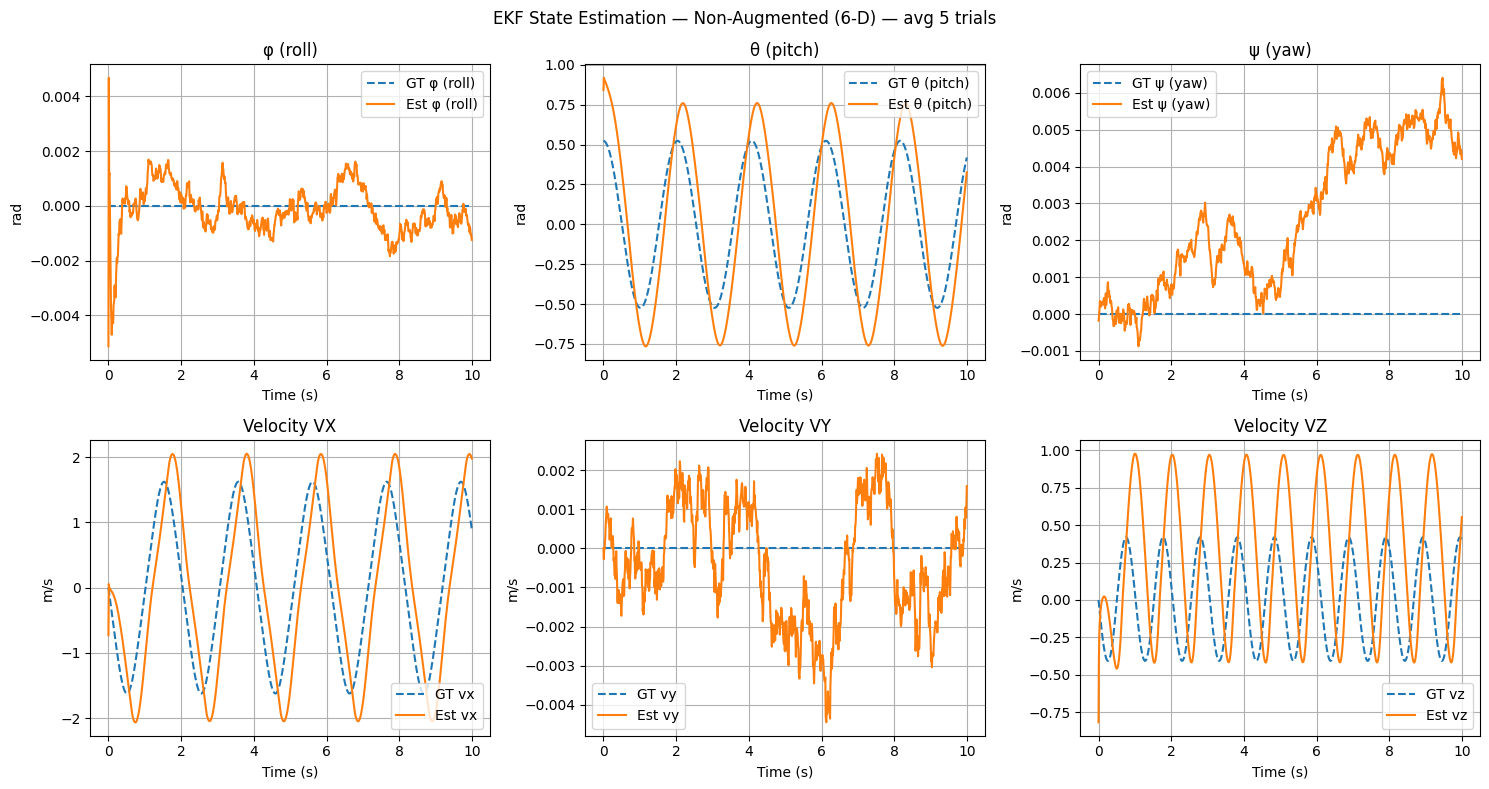

In [9]:
def plot_result(result: TrialResult):
    """Plot orientation and velocity estimates vs ground truth."""
    est = result.estimates
    t   = np.arange(len(est)) * DT

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"EKF State Estimation — {result.label}")

    for i, (lbl, key) in enumerate(zip(['φ (roll)', 'θ (pitch)', 'ψ (yaw)'],
                                       ['roll', 'pitch', 'yaw'])):
        axes[0, i].plot(t, result.gt[key], '--', label=f'GT {lbl}')
        axes[0, i].plot(t, est[:, i],            label=f'Est {lbl}')
        axes[0, i].set_title(lbl);  axes[0, i].set_ylabel('rad')
        axes[0, i].legend();        axes[0, i].grid(True)

    for i, (lbl, key) in enumerate(zip(['vx', 'vy', 'vz'], ['vx', 'vy', 'vz'])):
        axes[1, i].plot(t, result.gt[key], '--', label=f'GT {lbl}')
        axes[1, i].plot(t, est[:, 3 + i],       label=f'Est {lbl}')
        axes[1, i].set_title(f'Velocity {lbl.upper()}');  axes[1, i].set_ylabel('m/s')
        axes[1, i].legend();  axes[1, i].grid(True)

    for row in axes:
        for ax in row:
            ax.set_xlabel('Time (s)')
    plt.tight_layout();  plt.show()

plot_result(result_aug)
plot_result(result_non_aug)


## Summary table  (RMSE, MAE, max — averaged over 5 trials)

In [10]:
labels = ['φ', 'θ', 'ψ', 'vx', 'vy', 'vz']
units  = ['rad']*3 + ['m/s']*3

na  = result_non_aug
aug = result_aug

rmse_na  = np.concatenate([na.rmse_angles,  na.rmse_vel])
rmse_aug = np.concatenate([aug.rmse_angles, aug.rmse_vel])

max_na   = np.concatenate([na.max_angles,   na.max_vel])
max_aug  = np.concatenate([aug.max_angles,  aug.max_vel])

header = f"{'Metric':<18} {'State':<6} {'Unit':<5}" + f"{'Non-Aug':>9} {'Aug':>9} {'Δ':>9}"
print(header)
print("=" * len(header))
for metric, vals_na, vals_aug in [('RMSE', rmse_na, rmse_aug),
                                   ('Max',  max_na,  max_aug)]:
    for i, (lbl, unit) in enumerate(zip(labels, units)):
        delta = vals_aug[i] - vals_na[i]
        print(f"{metric:<18} {lbl:<6} {unit:<5}"
              f"{vals_na[i]:>9.4f} {vals_aug[i]:>9.4f} {delta:>+9.4f}")
    print()


Metric             State  Unit   Non-Aug       Aug         Δ
RMSE               φ      rad     0.0009    0.0012   +0.0003
RMSE               θ      rad     0.2624    0.2915   +0.0291
RMSE               ψ      rad     0.0027    0.0022   -0.0005
RMSE               vx     m/s     0.8070    0.5901   -0.2169
RMSE               vy     m/s     0.0018    0.0005   -0.0013
RMSE               vz     m/s     0.6162    0.3212   -0.2949

Max                φ      rad     0.0055    0.0056   +0.0001
Max                θ      rad     0.4008    0.3920   -0.0088
Max                ψ      rad     0.0054    0.0044   -0.0010
Max                vx     m/s     1.1541    0.9186   -0.2355
Max                vy     m/s     0.0047    0.0014   -0.0033
Max                vz     m/s     1.0669    0.5856   -0.4813

